# 06 — Market Basket Analysis (Spark MLlib FP-Growth)

Association-rule mining over UK purchase baskets using **Spark MLlib's parallel
FP-Growth** (`pyspark.ml.fpm.FPGrowth`), driven through `src.basket`.

FP-Growth (Han, Pei & Yin, 2000) mines frequent itemsets without candidate
generation; Spark MLlib implements its distributed variant, PFP (Li et al.,
2008). The dataset fits in memory, so distribution is not strictly required —
this demonstrates that the analytical pipeline scales to the larger transaction
volumes of production e-commerce.

**Design.** Baskets are built in pandas and handed to Spark as a DataFrame;
rules are pulled back to pandas. Spark performs only the mining, never local
file I/O — avoiding the Hadoop/`winutils` dependency on Windows.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt

from src.config import load_settings
from src.viz import set_style
from src.basket import build_baskets, get_spark_session, mine_rules, top_rules

set_style()

ROOT = Path.cwd().parent
settings = load_settings(ROOT / "config" / "settings.yaml")
B = settings["basket"]

FIG_DIR = ROOT / settings["paths"]["reports"] / "figures"
TBL_DIR = ROOT / settings["paths"]["reports"] / "tables"
GOLD = ROOT / settings["paths"]["gold"]


def savefig(fig, name):
    fig.savefig(FIG_DIR / f"06_{name}.png", dpi=150, bbox_inches="tight")


def savetable(df, name):
    df.to_csv(TBL_DIR / f"06_{name}.csv", index=False)

## 1. Build baskets (pandas)

In [2]:
tx = pd.read_parquet(ROOT / settings["paths"]["silver"] / "transactions_clean.parquet")
baskets = build_baskets(tx)

print(f"baskets: {len(baskets):,}")
print(f"single-item baskets: {(baskets['n_items'] == 1).sum():,}")
print(baskets["n_items"].describe().round(1))
baskets.head()

baskets: 33,374
single-item baskets: 2,590
count    33374.0
mean        20.6
std         22.4
min          1.0
25%          6.0
50%         15.0
75%         27.0
max        540.0
Name: n_items, dtype: float64


,Invoice,items,n_items
0,489434,"[15CM CHRISTMAS GLASS BALL 20 LIGHTS, FANCY FO...",8
1,489435,"[CAT BOWL, DOG BOWL , CHASING BALL DESIGN, HEA...",4
2,489436,"[AREA PATROLLED METAL SIGN, ASSORTED COLOUR BI...",19
3,489437,"[BLUE PADDED SOFT MOBILE, CHOCOLATE HOT WATER ...",23
4,489438,"[CARROT CHARLIE+LOLA COASTER SET, CHARLIE & LO...",17


## 2. Mine with Spark FP-Growth

`get_spark_session` returns a Windows-safe local session; `mine_rules` fits
FP-Growth and returns both the frequent itemsets and the association rules.

In [3]:
spark = get_spark_session("market-basket")
print("Spark", spark.version)

freq, rules = mine_rules(
    baskets, spark,
    min_support=B["min_support"],
    min_confidence=B["min_confidence"],
    min_lift=B["min_lift"],
)
spark.stop()
print(f"frequent itemsets (min_support={B['min_support']}): {len(freq):,}")
print(f"rules (min_confidence={B['min_confidence']}, min_lift={B['min_lift']}): {len(rules):,}")

Spark 4.1.2


frequent itemsets (min_support=0.02): 182
rules (min_confidence=0.3, min_lift=1.0): 15


## 3. Frequent itemsets

In [4]:
freq[["itemset", "length", "freq"]].head(15)

,itemset,length,freq
0,WHITE HANGING HEART T-LIGHT HOLDER,1,4701
1,REGENCY CAKESTAND 3 TIER,1,2856
2,ASSORTED COLOUR BIRD ORNAMENT,1,2504
3,JUMBO BAG RED RETROSPOT,1,2391
4,PARTY BUNTING,1,1941
5,LUNCH BAG BLACK SKULL.,1,1902
6,REX CASH+CARRY JUMBO SHOPPER,1,1843
7,HOME BUILDING BLOCK WORD,1,1768
8,HEART OF WICKER SMALL,1,1730
9,HEART OF WICKER LARGE,1,1721


## 4. Association rules

In [5]:
rules[["antecedent", "consequent", "support", "confidence", "lift"]].head(20)

,antecedent,consequent,support,confidence,lift
0,STRAWBERRY CERAMIC TRINKET BOX,SWEETHEART CERAMIC TRINKET BOX,0.022652,0.456246,13.880366
1,SWEETHEART CERAMIC TRINKET BOX,STRAWBERRY CERAMIC TRINKET BOX,0.022652,0.689152,13.880366
2,WOODEN PICTURE FRAME WHITE FINISH,WOODEN FRAME ANTIQUE WHITE,0.029124,0.603352,11.713943
3,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,0.029124,0.565445,11.713943
4,LOVE BUILDING BLOCK WORD,HOME BUILDING BLOCK WORD,0.022892,0.528354,9.973580
5,HOME BUILDING BLOCK WORD,LOVE BUILDING BLOCK WORD,0.022892,0.432127,9.973580
6,HEART OF WICKER LARGE,HEART OF WICKER SMALL,0.025619,0.496804,9.584013
7,HEART OF WICKER SMALL,HEART OF WICKER LARGE,0.025619,0.494220,9.584013
8,LUNCH BAG BLACK SKULL.,LUNCH BAG SPACEBOY DESIGN,0.021903,0.384332,7.639491
9,LUNCH BAG SPACEBOY DESIGN,LUNCH BAG BLACK SKULL.,0.021903,0.435378,7.639491


## 5. Visualize

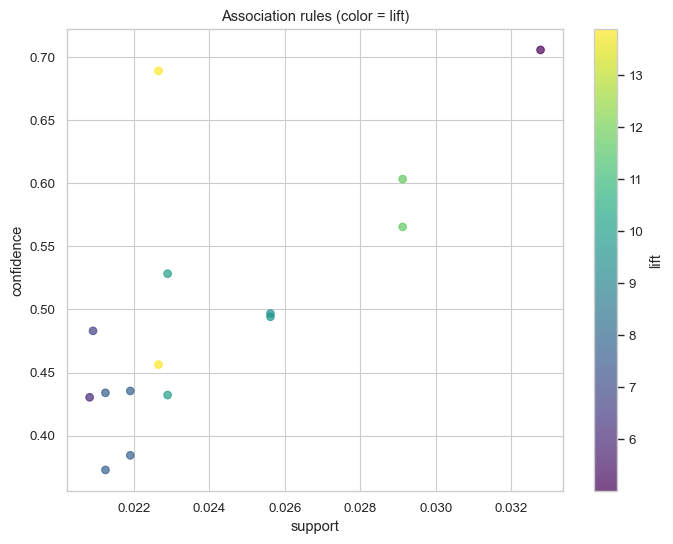

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(rules["support"], rules["confidence"],
                c=rules["lift"], cmap="viridis", s=30, alpha=0.7)
ax.set_xlabel("support")
ax.set_ylabel("confidence")
ax.set_title("Association rules (color = lift)")
fig.colorbar(sc, label="lift")
savefig(fig, "rules_scatter")
plt.show()

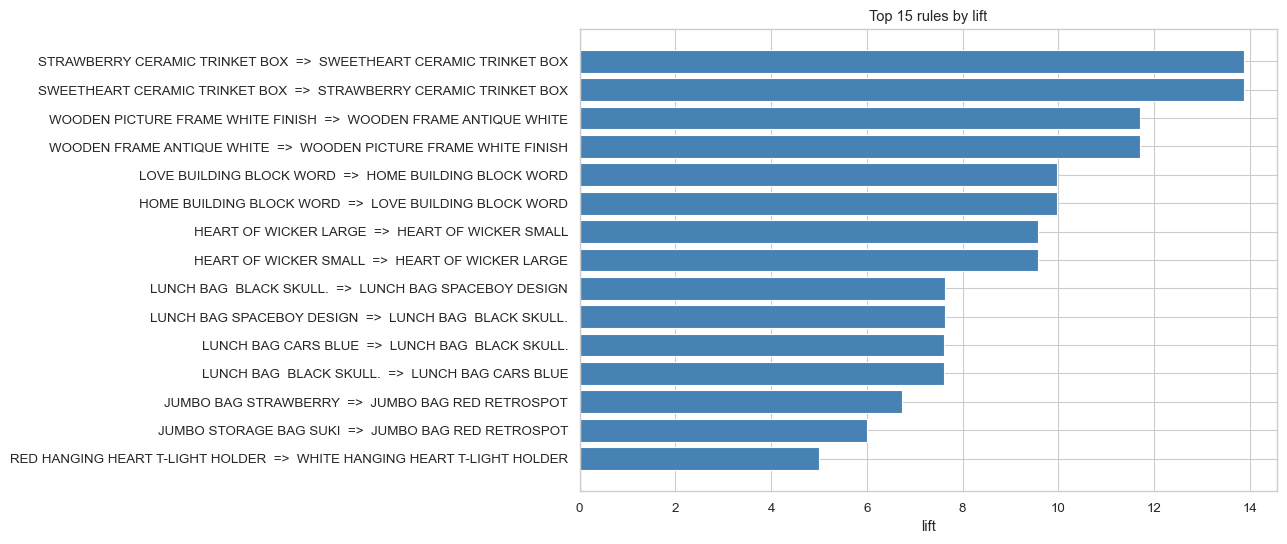

In [7]:
top = top_rules(rules, by="lift", n=15).copy()
top["rule"] = top["antecedent"] + "  =>  " + top["consequent"]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["rule"][::-1], top["lift"][::-1], color="steelblue")
ax.set_xlabel("lift")
ax.set_title("Top 15 rules by lift")
savefig(fig, "top_rules_lift")
plt.show()

## 6. Save gold/basket_rules.parquet

In [8]:
out = rules[["antecedent", "consequent", "support", "confidence", "lift"]]
out_path = GOLD / "basket_rules.parquet"
out.to_parquet(out_path, index=False)
savetable(top_rules(rules, by="lift", n=50), "top50_rules")
print(f"saved: {out_path}  ({len(out):,} rules)")

saved: D:\disertatie v2\Customer Behavior Analysis\data\gold\basket_rules.parquet  (15 rules)


## Key findings

- **Engine.** Rules were mined with Spark MLlib's parallel FP-Growth (Li et al.,
  2008), the distributed form of FP-Growth (Han, Pei & Yin, 2000); the classical
  Apriori association-rule framework is due to Agrawal & Srikant (1994).
- **Interpretation.** *Support* is the share of baskets containing an itemset;
  *confidence* is the conditional purchase probability; *lift* > 1 indicates
  products bought together more than chance — the actionable signal for
  cross-sell and store/site layout.
- **Scalability.** Although the present data fits in memory, the FP-Growth
  implementation runs unchanged on a Spark cluster, demonstrating the pipeline
  scales to production-volume transaction logs.
- **Link to segmentation.** These rules complement the per-segment top-product
  tables (nb 05), connecting *who* the valuable customers are with *what* they
  buy together.